Mohd Nizam Shaikh - 24198170 - MSc Fintech(MSCFTD1)

Read CSV file

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("synthetic_insurance_data.csv")
df.head()

,Age,Is_Senior,Marital_Status,Married_Premium_Discount,Prior_Insurance,Prior_Insurance_Premium_Adjustment,Claims_Frequency,Claims_Severity,Claims_Adjustment,Policy_Type,...,Time_Since_First_Contact,Conversion_Status,Website_Visits,Inquiries,Quotes_Requested,Time_to_Conversion,Credit_Score,Premium_Adjustment_Credit,Region,Premium_Adjustment_Region
0,47,0,Married,86,1-5 years,50,0,Low,0,Full Coverage,...,10,0,5,1,2,99,704,-50,Suburban,50
1,37,0,Married,86,1-5 years,50,0,Low,0,Full Coverage,...,22,0,5,1,2,99,726,-50,Urban,100
2,49,0,Married,86,1-5 years,50,1,Low,50,Full Coverage,...,28,0,4,4,1,99,772,-50,Urban,100
3,62,1,Married,86,>5 years,0,1,Low,50,Full Coverage,...,4,1,6,2,2,2,809,-50,Urban,100
4,36,0,Single,0,>5 years,0,2,Low,100,Full Coverage,...,14,1,8,4,2,10,662,50,Suburban,50


Check for missing data in columns like Age, Marital_Status, Claims_Severity, if yes then fill missing values

In [8]:
df[["Age", "Marital_Status", "Claims_Severity"]].isnull().sum()

Age                0
Marital_Status     0
Claims_Severity    0
dtype: int64

Identify and remove duplicate records, if any.

In [9]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of       Age  Is_Senior Marital_Status  Married_Premium_Discount Prior_Insurance  \
0      47          0        Married                        86       1-5 years   
1      37          0        Married                        86       1-5 years   
2      49          0        Married                        86       1-5 years   
3      62          1        Married                        86        >5 years   
4      36          0         Single                         0        >5 years   
...   ...        ...            ...                       ...             ...   
9995   59          1         Single                         0       1-5 years   
9996   18          0        Married                        86       1-5 years   
9997   29          0        Married                        86         <1 year   
9998   47          0         Single                         0         <1 year   
9999   49          0       Divorced                         0     

Sum the Total_Discounts column to find out the total discount across all customers.

In [11]:
print(f"Total_Discounts: {df["Total_Discounts"].sum()}")

Total_Discounts: 301100


Find how many customers have an Age greater than 50.

In [27]:
print(f"Number of people above 50: {df[df["Age"] > 50].shape[0]}")

Number of people above 50: 2284


Find how many people are married, single, etc., in the Marital_Status column.

In [13]:
print(df["Marital_Status"].value_counts())

Marital_Status
Married     4899
Single      3259
Widowed      922
Divorced     920
Name: count, dtype: int64


Calculate the range and average of the Premium_Amount.

In [29]:
print(f"Range: {df["Premium_Amount"].max() - df["Premium_Amount"].min()}, Average: {df["Premium_Amount"].mean():.2f}")

Range: 1136, Average: 2219.57


Calculate the mean, median, standard deviation, min, and max values for numerical features such as Age, Premium_Amount, Claims_Frequency

In [30]:
print(df[["Age", "Premium_Amount", "Claims_Frequency"]].describe())

                Age  Premium_Amount  Claims_Frequency
count  10000.000000    10000.000000      10000.000000
mean      39.991700     2219.571400          0.497200
std       14.050358      148.521132          0.716131
min       18.000000     1800.000000          0.000000
25%       29.000000     2100.000000          0.000000
50%       39.000000     2236.000000          0.000000
75%       50.000000     2336.000000          1.000000
max       90.000000     2936.000000          5.000000


For categorical variables like Marital_Status, Prior_Insurance, and Conversion_Status, analyze the distribution (e.g., how many are married vs. single, how many had prior insurance).

In [31]:
marital_status_distribution = df["Marital_Status"].value_counts()
print(marital_status_distribution)

Marital_Status
Married     4899
Single      3259
Widowed      922
Divorced     920
Name: count, dtype: int64


In [32]:
prior_insurance_distribution = df["Prior_Insurance"].value_counts()
print(prior_insurance_distribution)

Prior_Insurance
1-5 years    5257
>5 years     2609
<1 year      2134
Name: count, dtype: int64


Histograms: Visualize the distribution of continuous variables like Age, Premium_Amount, Claims_Frequency.

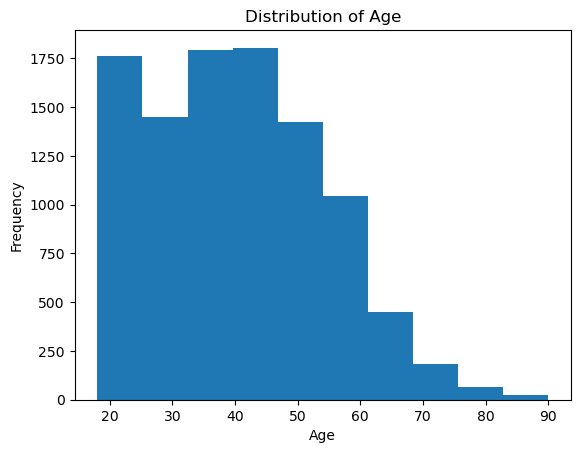

In [33]:
import matplotlib.pyplot as plt
plt.hist(df["Age"], bins=10)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Create new features by combining existing features, like combining Policy_Type with Premium_Amount to understand how different policy types affect premiums.

In [34]:
df["Policy_Premium_Combined"] = df["Policy_Type"] + '_' + df["Premium_Amount"].astype(str)

Discounts vs. Claims: Analyze how different types of discounts (Safe_Driver_Discount, Multi_Policy_Discount, etc.) affect the likelihood of a customer filing claims and their total premium amount.

In [35]:
discount_claims = df.groupby(["Safe_Driver_Discount", "Multi_Policy_Discount"])["Claims_Frequency"].mean()
print(discount_claims)

Safe_Driver_Discount  Multi_Policy_Discount
0                     0                        0.489910
                      1                        0.498980
1                     0                        0.521086
                      1                        0.501667
Name: Claims_Frequency, dtype: float64


In [36]:
discount_premium = df.groupby(["Safe_Driver_Discount", "Multi_Policy_Discount"])["Premium_Amount"].sum()
print(discount_premium)

Safe_Driver_Discount  Multi_Policy_Discount
0                     0                        12447588
                      1                         5389570
1                     0                         3074942
                      1                         1283614
Name: Premium_Amount, dtype: int64
